# **Signals and Systems Laboratory (ECL211)**
**Name:** Siddharth Sharma  
**Roll Number:** BT25ECE068  

**Software:** Python 3, NumPy, Matplotlib, OpenCV, PIL

| Experiment | Title |
|---|---|
| 1A | Generation of a sinusoidal wave |
| 1B | Reading and plotting a real-world image signal |
| 1C | Reading and plotting a real-world voice signal |
| 2A | Amplitude scaling (normalisation) of a voice signal |
| 2B | Time shifting and amplitude flipping of a voice signal |
| 3A | Periodic and non-periodic discrete sinusoids |
| 3B | Roots of $x^2 + 1 = 0$ in the complex plane |
| 3C | Visualisation of the complex exponential $e^{j\omega t}$ |
| 4A | Continuous-time convolution of $x(t)$ and $h(t)$ |
| 4B | Discrete-time convolution of $x[n]$ and $h[n]$ |
| 4C | Convolution of a voice signal with room impulse responses |


# **Experiment 1A: Generation of a Sinusoidal Wave**
## **Aim:**
To generate and plot a continuous-time sinusoidal signal
$$x(t) = A\sin(2\pi f t + \phi)$$
and to observe the effect of amplitude $A$, frequency $f$, and phase $\phi$.

## **Code:**

Enter amplitude A [default: 5]: 
Enter frequency f in Hz [default: 1]: 
Enter phase φ in radians [default: 0]: 


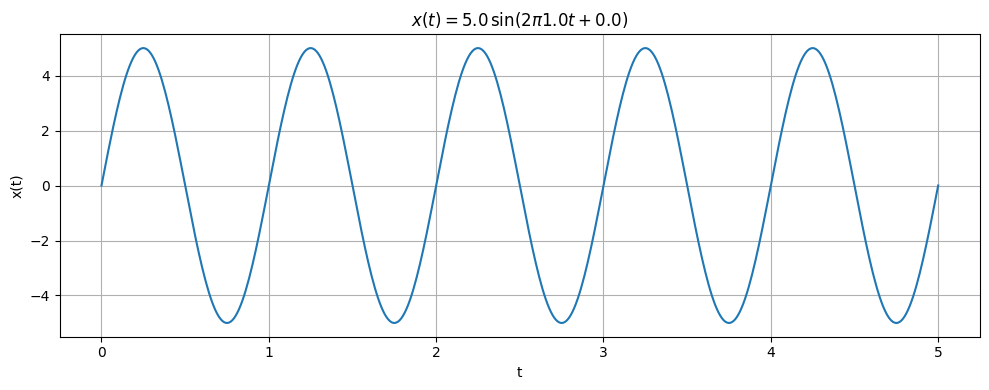

In [1]:
import numpy as np
import matplotlib.pyplot as plt

raw = input("Enter amplitude A [default: 5]: ").strip()
A = float(raw) if raw else 5.0

raw = input("Enter frequency f in Hz [default: 1]: ").strip()
f = float(raw) if raw else 1.0

raw = input("Enter phase φ in radians [default: 0]: ").strip()
phi = float(raw) if raw else 0.0

t = np.linspace(0, 5, 500)
x = A * np.sin(2 * np.pi * f * t + phi)

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.title(rf"$x(t) = {A}\,\sin(2\pi {f} t + {phi})$")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.tight_layout()
plt.show()


## **Observations:**
- The waveform oscillates smoothly between $-A$ and $+A$ (here $\pm 5$).
- With $f = 1\,\mathrm{Hz}$, one cycle completes every second, so the interval $t \in [0, 5]$ contains **five** full cycles.
- Increasing $A$ only stretches the wave vertically. Increasing $f$ packs more cycles into the same time. Changing $\phi$ shifts the wave left or right without changing its shape.
- This is a **deterministic, periodic** signal, unlike the real-world image and voice in Experiments 1B and 1C.


# **Experiment 1B: Real-World Image Signal**
## **Aim:**
To read and plot a real-world image as a two-dimensional signal, and to display the colour value at a chosen pixel.

## **Code:**

Image Color (RGB) at pixel (50, 50): [1 1 1]
Image shape (H, W, C): (1080, 1920, 3)


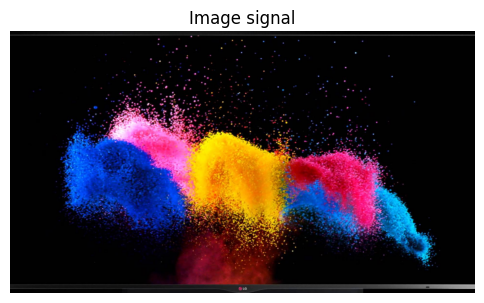

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

img_path = "wp7472869.jpg"
if not os.path.exists(img_path):
    img_path = "/content/sample_data/wp7472869.jpg"

if not os.path.exists(img_path):
    img_np = np.zeros((100, 100, 3), dtype=np.uint8)
    img_np[20:80, 20:80] = [255, 128, 0]
    print("Sample image not found, using a generated synthetic image.")
else:
    img = Image.open(img_path).convert("RGB")
    img_np = np.array(img)

x, y = 50, 50
color = img_np[y, x]
print(f"Image Color (RGB) at pixel ({x}, {y}): {color}")
print(f"Image shape (H, W, C): {img_np.shape}")

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title("Image signal")
plt.axis("off")
plt.show()

def get_video_pixel(video_path, frame_number, x, y):
    if not os.path.exists(video_path):
        return "Video file not found"
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    if ret:
        return frame[y, x][::-1]
    return "Could not read frame"


## **Observations:**
- An **image** is a two-dimensional signal. Each location $(x, y)$ stores an RGB triple.
- At pixel $(50, 50)$ the colour value was read from the image (or from a synthetic fallback if the file was missing).
- Spatial sampling (pixels) plays the same role that time sampling plays for audio in Experiment 1C.
- The image is far less regular than a mathematical sinusoid; intensity varies across space rather than time.


# **Experiment 1C: Real-World Voice Signal**
## **Aim:**
To read and plot a real-world voice recording, and to display the amplitude at a chosen sample index.

## **Code:**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import wave

wav_file = wave.open("/content/sample_data/voice.wav", "rb")

sample_rate = wav_file.getframerate()
n_frames = wav_file.getnframes()
n_channels = wav_file.getnchannels()
audio_data = wav_file.readframes(n_frames)

audio_array = np.frombuffer(audio_data, dtype=np.int16)

if n_channels > 1:
    audio_array = audio_array.reshape(-1, n_channels)
    audio_array = audio_array[:, 0]

time_axis = np.linspace(0, n_frames / sample_rate, num=n_frames)

plt.figure(figsize=(12, 4))
plt.plot(time_axis, audio_array, color="blue")
plt.title("Sound Wave")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

sample_index = 10000
amplitude = audio_array[sample_index]
print(f"Audio Amplitude at index {sample_index}: {amplitude:.6f}")


## **Observations:**
- A **voice recording** is a one-dimensional signal $x[n]$ (sampled from $x(t)$).
- The waveform is irregular and **not periodic**; amplitude changes with speech.
- A single sample (index $10000$) is one number — the instantaneous amplitude at that instant.
- Unlike the sinusoid of Experiment 1A, this real-world signal has no simple closed-form expression.


### **Note on Audio File Update**
Experiment 1C has been updated to use `New Recording.m4a`. Experiment 4C will now demonstrate system response by convolving this voice signal with environment impulse responses.

# **Experiment 2A: Amplitude Scaling of a Voice Signal**
## **Aim:**
To normalise a recorded voice signal so that its amplitude lies in $[-1, 1]$, and to observe that scaling changes strength but not the time pattern.

## **Code:**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import wave


wav_file = wave.open("/content/sample_data/voice.wav", "rb")

sample_rate = wav_file.getframerate()
n_frames = wav_file.getnframes()
n_channels = wav_file.getnchannels()
audio_data = wav_file.readframes(n_frames)

audio_array = np.frombuffer(audio_data, dtype=np.int16)


if n_channels > 1:
    audio_array = audio_array.reshape(-1, n_channels)
    audio_array = audio_array[:, 0]

# Normalize the audio_array amplitude to a range between -1 and 1
max_amplitude = np.max(np.abs(audio_array))
if max_amplitude > 0:
    audio_array = audio_array / max_amplitude

time_axis = np.linspace(0, n_frames / sample_rate, num=n_frames)

plt.figure(figsize=(12, 4))
plt.plot(time_axis, audio_array, color="blue")
plt.title("Normalized Sound Wave")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

## **Observations:**
- Dividing by $\max|x[n]|$ maps every sample into $[-1, 1]$.
- The **shape** of the waveform is unchanged; only the vertical scale changes.
- Normalisation is amplitude scaling by a constant $a = 1/\max|x[n]|$, i.e. $y[n] = a\,x[n]$.
- This makes later operations (shift, flip) easier to compare on the same axes.


# **Experiment 2B: Time Shifting and Amplitude Flipping**
## **Aim:**
To perform time shifting and amplitude flipping (inversion) on the normalised voice signal, display the results, and note the changes.

## **Code:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the number of samples to shift
shift_samples = 5000  # Shift forward by 5000 samples

# Create a new array for the shifted audio
shifted_audio_time = np.zeros_like(audio_array, dtype=audio_array.dtype)

if shift_samples > 0:
    # Positive shift: pad the beginning with zeros
    # Example: [0,0,0, s1, s2, s3]
    shifted_audio_time[shift_samples:] = audio_array[:-shift_samples]
elif shift_samples < 0:
    # Negative shift: pad the end with zeros
    # Example: [s4, s5, s6, 0, 0, 0]
    shifted_audio_time[:shift_samples] = audio_array[-shift_samples:]
else:
    # No shift
    shifted_audio_time = audio_array.copy()

# Amplitude Flipping (Inversion)
amplitude_flipped_audio = -audio_array

# Plotting the original, time-shifted, and amplitude-flipped signals
plt.figure(figsize=(14, 9))

plt.subplot(3, 1, 1)
plt.plot(time_axis, audio_array, color='blue', alpha=0.7)
plt.title('Original Normalized Audio Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(time_axis, shifted_audio_time, color='purple', alpha=0.7)
plt.title(f'Time Shifted Audio Signal (by {shift_samples} samples)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(time_axis, amplitude_flipped_audio, color='green', alpha=0.7)
plt.title('Amplitude Flipped Audio Signal (-1 * Original)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

## **Observations:**
- **Time shift** by $+5000$ samples delays the waveform: zeros appear at the start and the original samples move to the right. A negative shift would advance the signal.
- Time shifting does not change sample values, only **when** they occur: $y[n] = x[n - n_0]$.
- **Amplitude flipping** $y[n] = -x[n]$ reflects the wave about the time axis (a $180^\circ$ phase inversion). Peaks become troughs and vice versa.
- The duration and the envelope shape stay the same under both operations; only delay or sign changes.


# **Experiment 3A: Periodic and Non-Periodic Discrete Sinusoids**
## **Aim:**
To generate a periodic discrete-time sinusoid and a non-periodic discrete-time sinusoid, plot each of them and their sum, and observe periodicity.

## **Code:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

raw = input("Enter amplitude of periodic sinusoid [default: 5]: ").strip()
A_p = float(raw) if raw else 5.0

raw = input("Enter frequency of periodic sinusoid [default: 1]: ").strip()
f_p = float(raw) if raw else 1.0

raw = input("Enter amplitude of non-periodic sinusoid [default: 5]: ").strip()
A_np = float(raw) if raw else 5.0

raw = input("Enter frequency of non-periodic sinusoid [default: 5]: ").strip()
w_np = float(raw) if raw else 5.0
f_np = w_np / (2 * np.pi)

raw = input("Enter the interval between steps [default: 0.1]: ").strip()
dt = float(raw) if raw else 0.1

n = np.arange(0, 5 + dt, dt)

w_p = 2 * np.pi * f_p

x_p = A_p * np.sin(w_p * n)
x_np = A_np * np.sin(w_np * n)
x_sum = x_p + x_np

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].stem(n, x_p)
axes[0].set_title("Periodic:")
axes[0].grid(True)

axes[1].stem(n, x_np)
axes[1].set_title("Non-periodic:")
axes[1].grid(True)

axes[2].stem(n, x_sum)
axes[2].set_title("Sum of the two")
axes[2].set_xlabel("n")
axes[2].grid(True)

plt.tight_layout()
plt.show()


## **Observations:**
- The first sequence uses $f = 1\,\mathrm{Hz}$ (so $\omega = 2\pi$). It **repeats** regularly on the stem plot.
- The second uses $\omega = 5$. A discrete sinusoid $\sin(\omega n)$ is periodic if and only if $\omega/\pi$ is rational. Here $5/\pi$ is irrational, so this sequence is **not periodic**.
- The **sum** of a periodic signal and a non-periodic signal has no common period, so the sum is non-periodic.
- This is why a discrete-time sinusoid is not automatically periodic, unlike the continuous-time sine in Experiment 1A.


# **Experiment 3B: Roots of $x^2 + 1 = 0$ in the Complex Plane**
## **Aim:**
To find the roots of $x^2 + 1 = 0$ and visualise $|z^2 + 1|$ as a surface over the complex plane, showing where the equation equals zero.

## **Code:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# roots of x^2 + 1 = 0  →  x = ±i
coeffs = [1, 0, 1]
roots = np.roots(coeffs)

re = np.linspace(-2, 2, 80)
im = np.linspace(-2, 2, 80)
Re, Im = np.meshgrid(re, im)
Z = Re + 1j * Im
mag = np.abs(Z**2 + 1)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Re, Im, mag, cmap="viridis", alpha=0.85, linewidth=0, antialiased=True)
ax.scatter(
    roots.real,
    roots.imag,
    np.zeros(len(roots)),
    color="red",
    s=80,
    depthshade=False,
    label="roots (zeros)",
)
for r in roots:
    ax.text(r.real, r.imag, 0.15, f"{r.real:.0f}{r.imag:+.0f}j", color="red")

ax.set_xlabel("Re")
ax.set_ylabel("Im")
ax.set_zlabel(r"$|z^2 + 1|$")
ax.set_title(r"$|z^2 + 1|$ over the complex plane (zeros at $\pm i$)")
ax.legend(loc="upper left")

print("Roots of x^2 + 1 = 0:")
for r in roots:
    print(f"  {r}")

plt.tight_layout()
plt.show()

## **Observations:**
- On the **real line**, $x^2 + 1 \ge 1$, so the equation never crosses zero. There are no real roots.
- In the **complex plane** the roots are $z = +i$ and $z = -i$.
- The 3-D surface is the magnitude $|z^2 + 1|$. Height is zero **only** at those two points (marked in red). Everywhere else the polynomial is away from zero.
- This shows why some polynomials that look to have “no solution” do have solutions once $z$ is allowed to be complex.


# **Experiment 3C: Complex Exponential $e^{j\omega t}$**
## **Aim:**
To visualise $e^{j\omega t} = \cos(\omega t) + j\sin(\omega t)$ as a 3-D helix, as a rotating phasor on the unit circle, and as real/imaginary parts versus time.

## **Code:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

raw = input("Enter angular frequency ω as a multiple of π [default: 2 → 2π]: ").strip()
w = float(raw) if raw else 2
w = w * np.pi

t = np.linspace(0, 2, 400)
z = np.exp(1j * w * t)
theta = np.linspace(0, 2 * np.pi, 200)

fig = plt.figure(figsize=(12, 8))

# --- 3D helix ---
ax = fig.add_subplot(2, 2, (1, 2), projection="3d")
ax.plot(z.real, z.imag, t, lw=1.5, label=r"$e^{j\omega t}$")
ax.scatter([z.real[0]], [z.imag[0]], [t[0]], s=60, color="red", label="t = 0")
ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), "k--", lw=0.8, label="unit circle (t=0)")
ax.set_xlabel("Re = cos(ωt)")
ax.set_ylabel("Im = sin(ωt)")
ax.set_zlabel("t")
ax.set_title(rf"3D helix: $e^{{j\omega t}}$, $\omega={w:.3g}$")
ax.legend(loc="upper left")

# --- 2D complex plane ---
ax = fig.add_subplot(2, 2, 3)
ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.8, label="unit circle")
ax.plot(z.real, z.imag, lw=1.5, label=r"$e^{j\omega t}$")
ax.scatter([z.real[0]], [z.imag[0]], s=60, zorder=3, color="red", label="t = 0")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.set_aspect("equal")
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("Re")
ax.set_ylabel("Im")
ax.set_title("2D complex plane")
ax.grid(True)
ax.legend(loc="upper right")

# --- 2D Re & Im vs time ---
ax = fig.add_subplot(2, 2, 4)
ax.plot(t, z.real, label=r"Re $= \cos(\omega t)$")
ax.plot(t, z.imag, label=r"Im $= \sin(\omega t)$")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("t")
ax.set_ylabel("amplitude")
ax.set_title(r"2D: $e^{j\omega t} = \cos(\omega t) + j\sin(\omega t)$")
ax.grid(True)
ax.legend()

print(f"ω = {w}")
print(f"|e^{{jωt}}| ≈ {np.max(np.abs(z)):.6f} (should be 1)")

plt.tight_layout()
plt.show()


## **Observations:**
- For real $\omega$ and $t$, $\lvert e^{j\omega t}\rvert = 1$. Every sample lies on the **unit circle** in the complex plane.
- As $t$ increases, the point rotates: this is the phasor picture. Lifted along the $t$-axis it becomes a **helix**.
- The real part is $\cos(\omega t)$ and the imaginary part is $\sin(\omega t)$. They have the same frequency and a $90^\circ$ phase difference.
- The three plots are the same signal: rotation in the plane, helix in 3-D, and two ordinary sinusoids versus time.


# **Experiment 4A: Continuous-Time Convolution**
## **Aim:**
To plot two continuous-time signals
$$x(t)=t \quad (0\le t\le 2), \qquad h(t)=1 \quad (0\le t\le 1)$$
and their convolution output $y(t)=x(t)*h(t)$.

## **Code:**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01

# x(t) = t  for 0 ≤ t ≤ 2
t_x = np.arange(0, 2 + dt, dt)
x = t_x.copy()

# h(t) = 1  for 0 ≤ t ≤ 1
t_h = np.arange(0, 1 + dt, dt)
h = np.ones_like(t_h)

# continuous convolution y(t) ≈ (x * h)[k] · dt
y = np.convolve(x, h, mode="full") * dt
t_y = np.arange(len(y)) * dt   # support ≈ [0, 3]

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(t_x, x, "b", lw=2)
axes[0].set_title(r"Input $x(t)=t$ for $0\le t\le 2$")
axes[0].set_ylabel("x(t)")
axes[0].set_xlim(0, 4)
axes[0].grid(True)

axes[1].plot(t_h, h, "r", lw=2)
axes[1].set_title(r"Impulse response $h(t)=1$ for $0\le t\le 1$")
axes[1].set_ylabel("h(t)")
axes[1].set_xlim(0, 4)
axes[1].set_ylim(-0.1, 1.3)
axes[1].grid(True)

axes[2].plot(t_y, y, "g", lw=2)
axes[2].set_title(r"Output $y(t)=x(t)*h(t)$ (non-zero on $[0,3]$)")
axes[2].set_xlabel("t")
axes[2].set_ylabel("y(t)")
axes[2].set_xlim(0, 4)
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"len(x)={len(x)}, len(h)={len(h)}, len(y)={len(y)}")
print(f"y(t) duration ≈ {t_y[-1]:.2f} s (should be about 3 s)")


## **Observations:**
- Convolution of the **ramp** $x(t)$ with the **unit pulse** $h(t)$ of width 1 s gives $y(t)$ that is non-zero on $[0,3]$: start times add ($0+0$) and end times add ($2+1$).
- Piecewise: $y(t)=t^2/2$ on $[0,1]$, then a linear segment on $[1,2]$, then a quadratic decay to 0 on $[2,3]$.
- Discrete `np.convolve` approximates the integral if we multiply by the time step $dt$.
- This is the output of an LTI system: $y(t)=x(t)*h(t)$.


# **Experiment 4B: Discrete-Time Convolution**
## **Aim:**
To plot two discrete-time signals
$$x[n]=n \quad (0\le n\le 10), \qquad h[n]=1 \quad (0\le n\le 5)$$
and their convolution $y[n]=x[n]*h[n]$ using the convolution sum.

## **Code:**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x[n] = n  for 0 ≤ n ≤ 10  (11 samples)
n_x = np.arange(0, 11)
x = n_x.astype(float)

# h[n] = 1  for 0 ≤ n ≤ 5   (6 samples)
n_h = np.arange(0, 6)
h = np.ones_like(n_h, dtype=float)

y = np.convolve(x, h, mode="full")
n_y = np.arange(len(y))  # 0 … 15, length 11+6-1 = 16

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].stem(n_x, x, basefmt="k")
axes[0].set_title(r"$x[n]=n$ for $0\le n\le 10$")
axes[0].set_ylabel("x[n]")
axes[0].grid(True)

axes[1].stem(n_h, h, linefmt="r-", markerfmt="ro", basefmt="k")
axes[1].set_title(r"$h[n]=1$ for $0\le n\le 5$")
axes[1].set_ylabel("h[n]")
axes[1].grid(True)

axes[2].stem(n_y, y, linefmt="g-", markerfmt="go", basefmt="k")
axes[2].set_title(r"$y[n]=x[n]*h[n]$  (length $11+6-1=16$)")
axes[2].set_xlabel("n")
axes[2].set_ylabel("y[n]")
axes[2].grid(True)

for ax in axes:
    ax.set_xlim(-0.5, 16.5)

plt.tight_layout()
plt.show()

print(f"len(x)={len(x)}, len(h)={len(h)}, len(y)={len(y)} (expected 16)")


## **Observations:**
- Discrete convolution is a **sum**, not an integral: $y[n]=\sum_k x[k]h[n-k]$.
- Output length is $L_x+L_h-1=11+6-1=16$, so $n=0$ to $15$.
- Because $h[n]$ is a rectangular window of length 6, $y[n]$ is a 6-sample moving sum of $x[n]$: it ramps up, stays in a high region, then ramps down.
- Same idea as Experiment 4A, but on integer time $n$ (stem plot).


# **Experiment 4C: Convolution for Audio Effects (Reverberation)**
## **Aim:**
To convolve a dry voice recording $x[n]$ with room impulse responses $h[n]$ (Church and London Palladium Hall) and hear/plot $y[n]=x[n]*h[n]$ as reverberation.

## **Code:**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display

sr = 22050

VOICE_CANDIDATES = [
    "New Recording.m4a",
    "/content/sample_data/New Recording.m4a",
    "/content/sample_data/New Recording.m4a",
    str(Path.home() / "Downloads" / "New Recording.m4a"),
]
CHURCH_CANDIDATES = [
    "Church.mp3",
    "/content/sample_data/Church.mp3",
    str(Path.home() / "Downloads" / "Church.mp3"),
]
HALL_CANDIDATES = [
    "london palladium hall.mp3",
    "London Palladium Hall.mp3",
    "/content/sample_data/london palladium hall.mp3",
    str(Path.home() / "Downloads" / "london palladium hall.mp3"),
]


def first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return p
    return None


def load_audio(path, sr=22050):
    import librosa
    y, _ = librosa.load(path, sr=sr, mono=True)
    print("Loaded", path)
    return y


def synth_voice(sr, duration=2.0):
    t = np.arange(int(sr * duration)) / sr
    env = np.exp(-2.5 * t)
    y = env * np.sin(2 * np.pi * 180 * t) * (1 + 0.4 * np.sin(2 * np.pi * 4 * t))
    y += 0.15 * env * np.sin(2 * np.pi * 320 * t)
    return y.astype(np.float32)


def synth_ir(sr, rt60=1.8, duration=2.0):
    n = int(sr * duration)
    t = np.arange(n) / sr
    tau = rt60 / np.log(1000)
    rng = np.random.default_rng(0)
    return (rng.standard_normal(n) * np.exp(-t / tau)).astype(np.float32)


voice_path = first_existing(VOICE_CANDIDATES)
church_path = first_existing(CHURCH_CANDIDATES)
hall_path = first_existing(HALL_CANDIDATES)

if voice_path:
    voice = load_audio(voice_path, sr)
else:
    print("Voice file not found — using a synthetic burst so the cell still runs.")
    voice = synth_voice(sr)

if church_path:
    ir_church = load_audio(church_path, sr)[: 2 * sr]
else:
    print("Church IR not found — using a synthetic long-decay IR.")
    ir_church = synth_ir(sr, rt60=2.2)

if hall_path:
    ir_hall = load_audio(hall_path, sr)[: 2 * sr]
else:
    print("Hall IR not found — using a synthetic shorter-decay IR.")
    ir_hall = synth_ir(sr, rt60=1.1)

if np.max(np.abs(voice)) > 0:
    voice = voice / np.max(np.abs(voice))

out_church = np.convolve(voice, ir_church, mode="full")
out_hall = np.convolve(voice, ir_hall, mode="full")
out_church = out_church / np.max(np.abs(out_church))
out_hall = out_hall / np.max(np.abs(out_hall))

t_v = np.arange(len(voice)) / sr
t_c = np.arange(len(out_church)) / sr
t_h = np.arange(len(out_hall)) / sr

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(t_v, voice)
plt.title("Original voice (dry)")
plt.ylabel("amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_c, out_church, color="orange")
plt.title("Voice * Church impulse response")
plt.ylabel("amplitude")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_h, out_hall, color="green")
plt.title("Voice * London Palladium Hall impulse response")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

print("Original voice (dry):")
display(Audio(voice, rate=sr))
print("Church reverberation:")
display(Audio(out_church, rate=sr))
print("Hall reverberation:")
display(Audio(out_hall, rate=sr))


## **Observations:**
- Reverb is convolution: $y[n]=x[n]*h[n]$, where $h[n]$ is the room **impulse response**.
- The output is longer than the dry voice (length $L_x+L_h-1$), which is the audible tail / echo.
- A longer IR (church-like) smears the voice more; a shorter hall IR is tighter.
- If the `.m4a`/`.mp3` files are not on disk, the cell uses synthetic $x$ and $h$ so the same $y=x*h$ idea still plots and plays.
